In [20]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

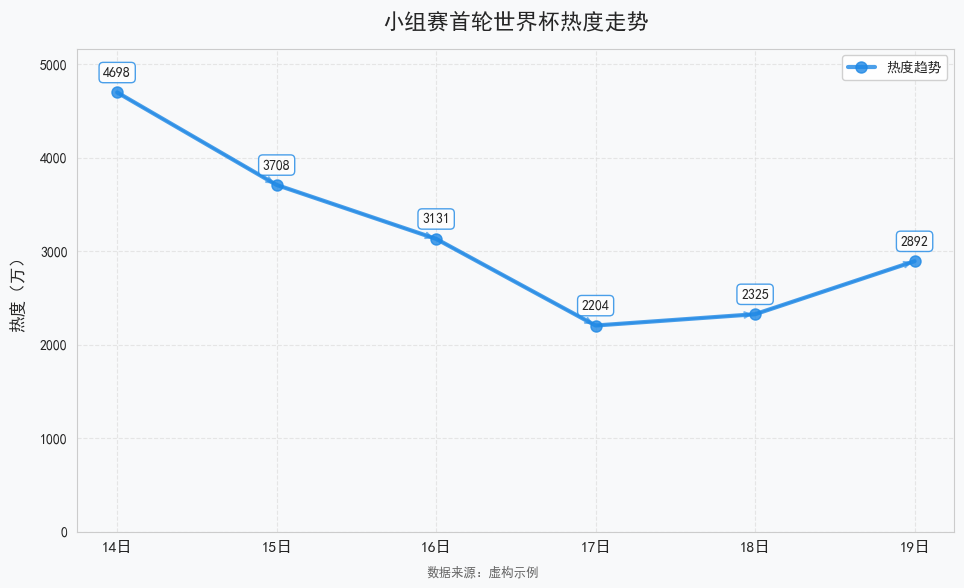

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 日期数据
dates = ["14日", "15日", "16日", "17日", "18日", "19日"]
# 热度数据（单位：万）
heat_values = [4698, 3708, 3131, 2204, 2325, 2892]

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#f8f9fa')

# 设置网格样式
ax.grid(True, linestyle='--', alpha=0.7, color='#dddddd')

# 绘制折线图，使用渐变色
x = np.arange(len(dates))
line, = ax.plot(x, heat_values, marker='o', markersize=8, 
                color='#1e88e5', linewidth=3, alpha=0.8)

# 添加数据标签
for i, (date, value) in enumerate(zip(dates, heat_values)):
    ax.annotate(f'{value}',
                xy=(i, value),
                xytext=(0, 10),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1e88e5", alpha=0.8))

# 设置x轴标签
ax.set_xticks(x)
ax.set_xticklabels(dates, fontsize=11)

# 设置y轴范围和标签
ax.set_ylim(0, max(heat_values) * 1.1)
ax.set_ylabel('热度（万）', fontsize=12, labelpad=10)

# 添加标题
ax.set_title('小组赛首轮世界杯热度走势', fontsize=16, pad=15, fontweight='bold')

# 添加背景色
ax.set_facecolor('#f8f9fa')

# 添加趋势箭头
for i in range(len(x)-1):
    ax.annotate('',
                xy=(x[i+1], heat_values[i+1]),
                xytext=(x[i], heat_values[i]),
                arrowprops=dict(arrowstyle='->', color='#1e88e5', lw=1.5, alpha=0.6))

# 添加图例
ax.legend(['热度趋势'], loc='upper right', frameon=True, framealpha=0.9)

# 添加底部说明
plt.figtext(0.5, 0.01, '数据来源：虚构示例', ha='center', fontsize=9, color='#666666')

# 优化布局
plt.tight_layout(pad=2)

# 保存图表（可选）
# plt.savefig('worldcup_heat_trend.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()    

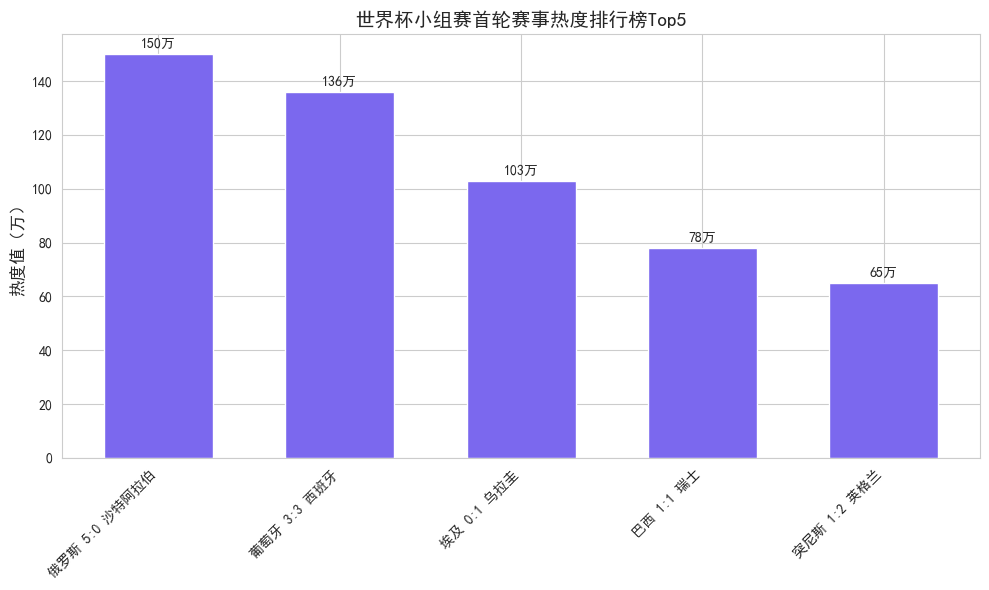

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 赛事数据（比赛对阵、比分、热度值）
matches = ["俄罗斯 5:0 沙特阿拉伯", 
           "葡萄牙 3:3 西班牙", 
           "埃及 0:1 乌拉圭", 
           "巴西 1:1 瑞士", 
           "突尼斯 1:2 英格兰"]
hot_values = [150, 136, 103, 78, 65]  # 热度值（单位：万，简化为数值）

# 用于在 X 轴显示
x = np.arange(len(matches))  

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6))
# 绘制柱状图
rects = ax.bar(x, hot_values, width=0.6, color="#7B68EE")  

# 设置 X 轴刻度与标签
ax.set_xticks(x)
ax.set_xticklabels(matches, rotation=45, ha="right", fontsize=10)  

# 设置 Y 轴标签
ax.set_ylabel("热度值（万）", fontsize=12)  
# 设置标题
ax.set_title("世界杯小组赛首轮赛事热度排行榜Top5", fontsize=14, fontweight="bold")  

# 在柱子上标注数值
for rect in rects:
    height = rect.get_height()
    ax.annotate(f"{height}万", 
                xy=(rect.get_x() + rect.get_width() / 2, height), 
                xytext=(0, 3),  # 向上偏移 3 个像素
                textcoords="offset points", 
                ha="center", va="bottom")

# 优化布局（避免标签显示不全）
plt.tight_layout()  
# 显示图表
plt.show()  

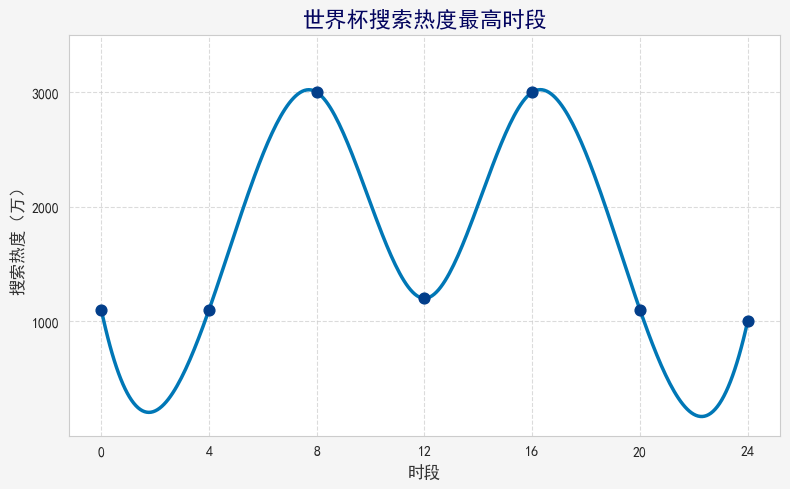

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 时段（x 轴数据）
hours = np.arange(0, 25, 4)
# 搜索热度（y 轴数据，单位：万）
heat_values = [1100, 1100, 3000, 1200, 3000, 1100, 1000]

# 创建画布
plt.figure(figsize=(8, 5), facecolor="#f5f5f5")

# 使用三次样条插值生成平滑曲线
x_smooth = np.linspace(hours.min(), hours.max(), 300)
spl = make_interp_spline(hours, heat_values, k=3)  # k=3 表示三次样条
y_smooth = spl(x_smooth)

# 绘制平滑曲线
plt.plot(x_smooth, y_smooth, color="#0077b6", linewidth=2.5)
# 绘制数据点
plt.scatter(hours, heat_values, color="#023e8a", s=60, zorder=5)

# 设置标题
plt.title("世界杯搜索热度最高时段", fontsize=16, fontweight="bold", color="#03045e")
# 设置 x 轴标签
plt.xlabel("时段", fontsize=12, color="#333333")
# 设置 y 轴标签
plt.ylabel("搜索热度（万）", fontsize=12, color="#333333")

# 设置 x 轴刻度
plt.xticks(hours)
# 设置 y 轴刻度
plt.yticks([1000, 2000, 3000])

# 添加网格线
plt.grid(True, linestyle="--", alpha=0.7)

# 美化图表
plt.tight_layout()  # 自动调整布局
plt.ylim(0, 3500)   # 设置y轴范围

# 显示图表
plt.show()

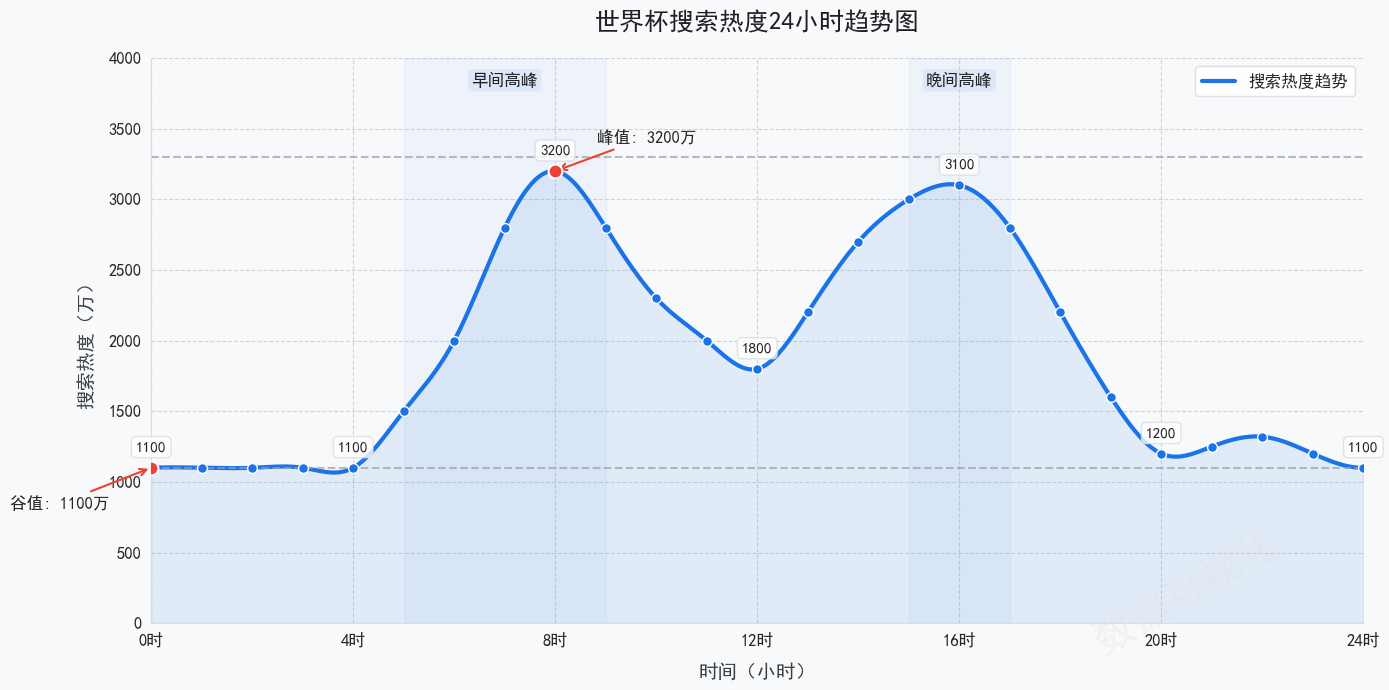

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# 每小时的搜索热度数据（单位：万）
hours = list(range(25))  # 0-24时
heat_data = [
    1100, 1100, 1100, 1100, 1100,  # 0-4时
    1500, 2000, 2800, 3200, 2800,  # 5-9时
    2300, 2000, 1800, 2200, 2700,  # 10-14时
    3000, 3100, 2800, 2200, 1600,  # 15-19时
    1200, 1250, 1320, 1200, 1100   # 20-24时
]

# 创建画布和子图
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

# 使用三次样条插值生成平滑曲线
x_smooth = np.linspace(min(hours), max(hours), 500)
spl = make_interp_spline(hours, heat_data, k=3)
heat_smooth = spl(x_smooth)

# 绘制平滑曲线，添加渐变色填充
line, = ax.plot(x_smooth, heat_smooth, linestyle='-', color='#1a73e8', linewidth=3)
ax.fill_between(x_smooth, heat_smooth, 0, alpha=0.1, color='#1a73e8')

# 添加参考水平线，优化线条样式
ax.axhline(y=1100, color='#9aa0a6', linestyle='--', alpha=0.7, linewidth=1.5)
ax.axhline(y=3300, color='#9aa0a6', linestyle='--', alpha=0.7, linewidth=1.5)

# 添加标题和标签，优化字体和位置
ax.set_title('世界杯搜索热度24小时趋势图', fontsize=18, pad=20, fontweight='bold', color='#202124')
ax.set_xlabel('时间（小时）', fontsize=14, labelpad=10, color='#3c4043')
ax.set_ylabel('搜索热度（万）', fontsize=14, labelpad=10, color='#3c4043')

# 设置x轴刻度，优化显示格式
ax.set_xticks(hours[::4])
ax.set_xticklabels([f'{h}时' for h in hours[::4]], fontsize=12)
ax.set_xlim(0, 24)
ax.set_ylim(0, 4000)

# 设置y轴刻度，优化显示格式
ax.set_yticks(np.arange(0, 4500, 500))
ax.set_yticklabels([f'{y}' for y in np.arange(0, 4500, 500)], fontsize=12)

# 添加网格线，优化样式
ax.grid(True, linestyle='--', alpha=0.4, color='#9aa0a6')

# 添加原始数据点，优化样式
ax.scatter(hours, heat_data, color='#1a73e8', s=50, zorder=5, edgecolor='white', linewidth=1)

# 为关键时间点添加数据标签，优化样式和位置
for x, y in zip(hours[::4], heat_data[::4]):
    ax.annotate(f'{y}', (x, y), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#dadce0', alpha=0.8))

# 突出显示峰值和谷值，优化样式
peak_idx = np.argmax(heat_data)
valley_idx = np.argmin(heat_data)
ax.scatter([hours[peak_idx], hours[valley_idx]], 
           [heat_data[peak_idx], heat_data[valley_idx]], 
           color='#ea4335', s=100, zorder=5, edgecolor='white', linewidth=1.5)

# 添加峰值和谷值的注释，优化样式
ax.annotate(f'峰值: {heat_data[peak_idx]}万', (hours[peak_idx], heat_data[peak_idx]),
            textcoords='offset points', xytext=(30, 20), ha='left', fontsize=12,
            arrowprops=dict(arrowstyle='->', color='#ea4335', linewidth=1.5))

ax.annotate(f'谷值: {heat_data[valley_idx]}万', (hours[valley_idx], heat_data[valley_idx]),
            textcoords='offset points', xytext=(-30, -30), ha='right', fontsize=12,
            arrowprops=dict(arrowstyle='->', color='#ea4335', linewidth=1.5))

# 添加时间区域提示，优化样式
ax.axvspan(5, 9, alpha=0.05, color='#4285f4', label='早间高峰')
ax.axvspan(15, 17, alpha=0.05, color='#4285f4')
ax.text(7, 3800, '早间高峰', ha='center', fontsize=12, color='#202124', 
        bbox=dict(boxstyle='round,pad=0.2', fc='#4285f4', alpha=0.1))
ax.text(16, 3800, '晚间高峰', ha='center', fontsize=12, color='#202124', 
        bbox=dict(boxstyle='round,pad=0.2', fc='#4285f4', alpha=0.1))

# 优化坐标轴样式
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dadce0')
ax.spines['bottom'].set_color('#dadce0')
ax.tick_params(axis='both', which='major', labelsize=12, color='#9aa0a6')

# 添加图例，优化样式
ax.legend([line], ['搜索热度趋势'], loc='upper right', frameon=True, 
          framealpha=0.9, edgecolor='#dadce0', fontsize=12)

# 添加水印，优化样式
fig.text(0.85, 0.15, '数据可视化', fontsize=30, color='#e0e0e0', 
         ha='center', va='center', rotation=30, alpha=0.3)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_39372\3080349028.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bars = ax.bar(x, heats, color=plt.cm.get_cmap('Purples')(np.linspace(0.2, 0.8, len(players))))


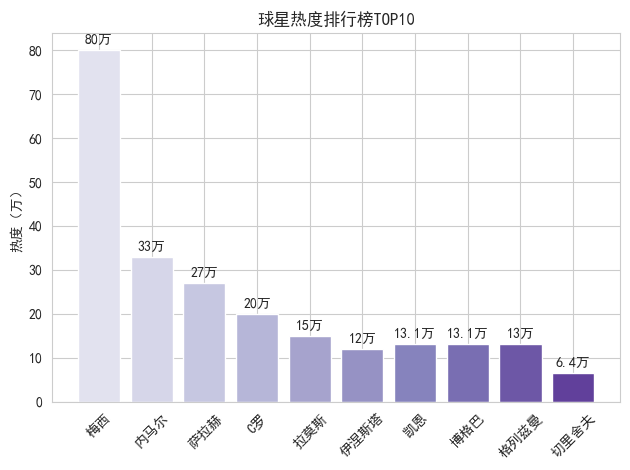

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# 球星名称
players = ["梅西", "内马尔", "萨拉赫", "C罗", "拉莫斯", "伊涅斯塔", "凯恩", "博格巴", "格列兹曼", "切里舍夫"]
# 热度数据
heats = [80, 33, 27, 20, 15, 12, 13.1, 13.1, 13, 6.4]
# 为了让 x 轴刻度对应球星，生成索引
x = np.arange(len(players))  

# 创建图形
fig, ax = plt.subplots()
# 绘制柱状图，设置柱子颜色为紫色到粉色渐变
bars = ax.bar(x, heats, color=plt.cm.get_cmap('Purples')(np.linspace(0.2, 0.8, len(players))))

# 设置 x 轴刻度显示球星名称
ax.set_xticks(x)
ax.set_xticklabels(players, rotation=45)  # 移除了fontproperties参数

# 设置 y 轴标签
ax.set_ylabel("热度（万）")
# 设置标题
ax.set_title("球星热度排行榜TOP10")

# 在柱子上标注数值
for bar, heat in zip(bars, heats):
    height = bar.get_height()
    ax.annotate(f'{heat}万',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 数值相对柱子的垂直偏移
                textcoords="offset points",
                ha='center', va='bottom')

# 调整布局，避免标签显示不全
plt.tight_layout()
# 显示图表
plt.show()